In [1]:
using Revise
using MajoranaPropagation
using MajoranaPropagation.QuantumChemistry
using PauliPropagation

using Plots 

In [2]:
# parse FCIDUMP file to get the Hamiltonian
filename = "utils/STO3G_HF"
H = parse_fcidump(filename; min_coeff=5.e-10, remove_identity=true)
@show length(H)
n_orbitals = H.nsites

length(H) = 5734


10

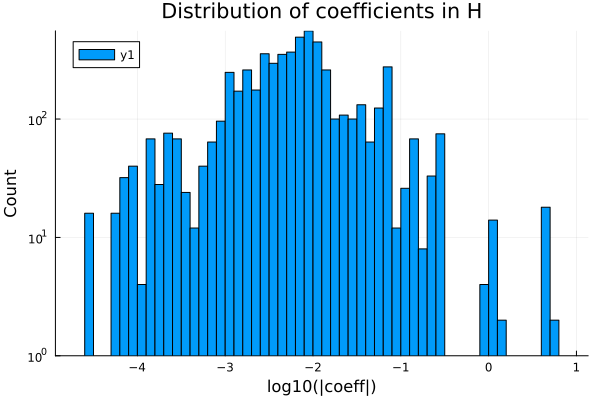

In [3]:
coeffs = log10.(abs.(coefficients(H)))
histogram(coeffs, bins=50, xlabel="log10(|coeff|)", ylabel="Count", title="Distribution of coefficients in H", yscale=:log10)

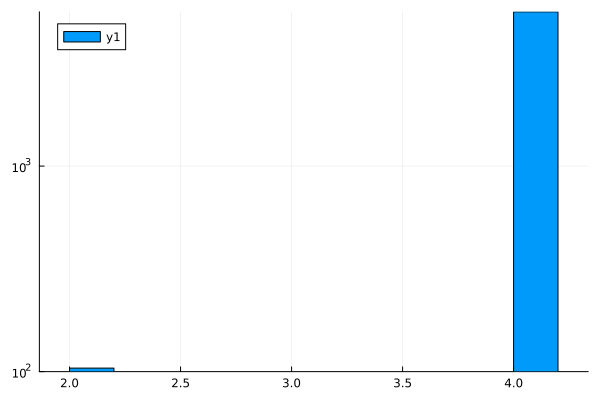

In [4]:
weights = get_weight.(MajoranaPropagation.majoranas(H))
histogram(weights, yscale=:log10)

In [5]:
up_electros = 1:2:n_orbitals
down_electros = 2:2:n_orbitals

fock_state = FockState(n_orbitals, up_electros, down_electros)
@show fock_state
overlapwithfock(H, fock_state)

fock_state = Fock state with 10 fermions at positions
    ↑: 1, 3, 5, 7, 9
    ↓: 2, 4, 6, 8, 10



3.9108594974365527

In [6]:
dt = 0.05
n_steps = 10

circ = []
thetas = []

for (ms, coeff) in H
    push!(circ, MajoranaRotation(ms))
    push!(thetas, 2*dt*coeff)
end

In [7]:
obs = MajoranaSum(n_orbitals, :nup, 1) * MajoranaSum(n_orbitals, :nup, 3) * MajoranaSum(n_orbitals, :nup, 5)

obs_vals = zeros(n_steps+1)
obs_lengths = zeros(Int, n_steps+1)

obs_vals[1] = overlapwithfock(obs, fock_state)
obs_lengths[1] = length(obs)

min_abs_coeff = 1.e-4

for i in 1:n_steps
    propagate!(circ, obs, thetas; min_abs_coeff=min_abs_coeff)
    obs_vals[i+1] = overlapwithfock(obs, fock_state)
    obs_lengths[i+1] = length(obs)
    @show i, obs_lengths[i+1]
end


(i, obs_lengths[i + 1]) = (1, 3996)
(i, obs_lengths[i + 1]) = (2, 6037)
(i, obs_lengths[i + 1]) = (3, 8358)
(i, obs_lengths[i + 1]) = (4, 11444)
(i, obs_lengths[i + 1]) = (5, 15175)
(i, obs_lengths[i + 1]) = (6, 18192)
(i, obs_lengths[i + 1]) = (7, 20961)
(i, obs_lengths[i + 1]) = (8, 23084)
(i, obs_lengths[i + 1]) = (9, 24758)
(i, obs_lengths[i + 1]) = (10, 25733)


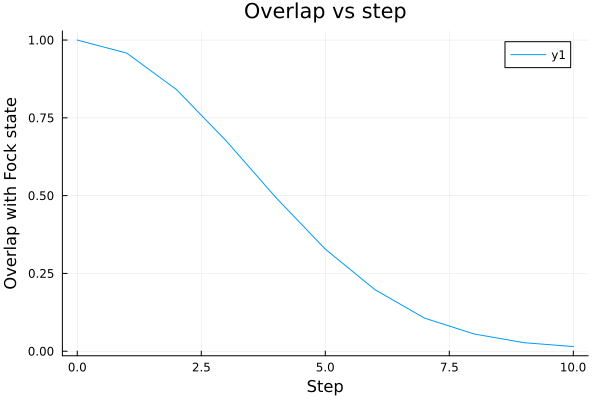

In [8]:
plot(0:n_steps, obs_vals, xlabel="Step", ylabel="Overlap with Fock state", title="Overlap vs step")

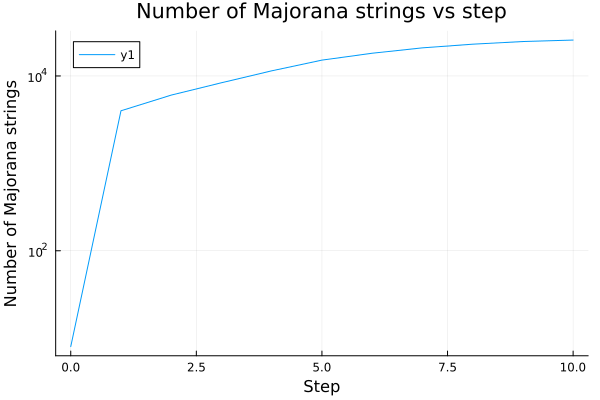

In [9]:
plot(0:n_steps, obs_lengths, xlabel="Step", ylabel="Number of Majorana strings", title="Number of Majorana strings vs step", yscale=:log10)